In [1]:
import tensorflow as tf
from tensorflow.keras import datasets , layers , models
import numpy as np
import matplotlib.pyplot as plt 


In [2]:
(x_train , y_train ) , (x_test , y_test) = datasets.cifar10.load_data()

In [3]:
x_test.shape

(10000, 32, 32, 3)

In [4]:
x_train.shape

(50000, 32, 32, 3)

In [5]:
y_train.shape

(50000, 1)

In [6]:
y_train = y_train.reshape(-1)

In [7]:
y_test = y_test.reshape(-1)

In [8]:
classes = ['airplane' , 'automobile' , 'bird' , 'cat' , 'deer' , 'dog' , 'frog' , 'truck']

In [9]:
def plot_sample(x ,y , index):
    plt.figure(figsize = (15,2))
    plt.imshow(x[index])
    plt.xlabel(classes[y[index]])

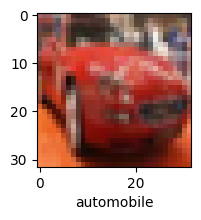

In [10]:
plot_sample(x_train , y_train , 5)

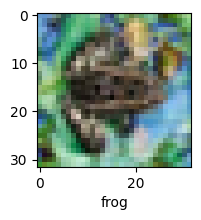

In [11]:
plot_sample(x_train , y_train , 200)

IndexError: list index out of range

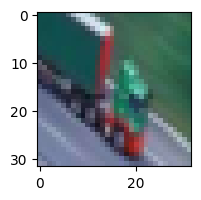

In [12]:
plot_sample(x_train , y_train , 50)

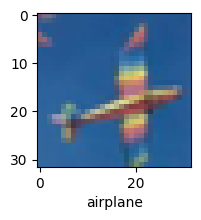

In [ ]:
plot_sample(x_train , y_train , 220)

In [13]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [14]:
ann = models.Sequential([
    layers.Flatten(input_shape = (32,32,3)),
    layers.Dense(3000 , activation= 'relu'),
    layers.Dense(1000 , activation  = 'relu'),
    layers.Dense(10 , activation = 'softmax')
])

C:\Users\Dilan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [15]:
ann.compile(optimizer= 'SGD' , loss = 'sparse_categorical_crossentropy' , metrics = ['accuracy'])

In [ ]:
ann.fit(x_train , y_train ,epochs= 5 )

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.3555 - loss: 1.8104
Epoch 2/5
1343/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.4144 - loss: 1.6538

In [ ]:
from sklearn.metrics import confusion_matrix , classification_report
predict = ann.predict(x_test)
predict_class = [np.argmax(element) for element in predict]
print('classification report : \n' , classification_report(y_test , predict_class))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
classification report : 
               precision    recall  f1-score   support

           0       0.46      0.67      0.55      1000
           1       0.51      0.73      0.60      1000
           2       0.31      0.52      0.39      1000
           3       0.38      0.40      0.39      1000
           4       0.55      0.20      0.30      1000
           5       0.45      0.30      0.36      1000
           6       0.60      0.42      0.50      1000
           7       0.56      0.55      0.55      1000
           8       0.69      0.48      0.57      1000
           9       0.54      0.52      0.53      1000

    accuracy                           0.48     10000
   macro avg       0.50      0.48      0.47     10000
weighted avg       0.50      0.48      0.47     10000



In [ ]:
import seaborn as sns


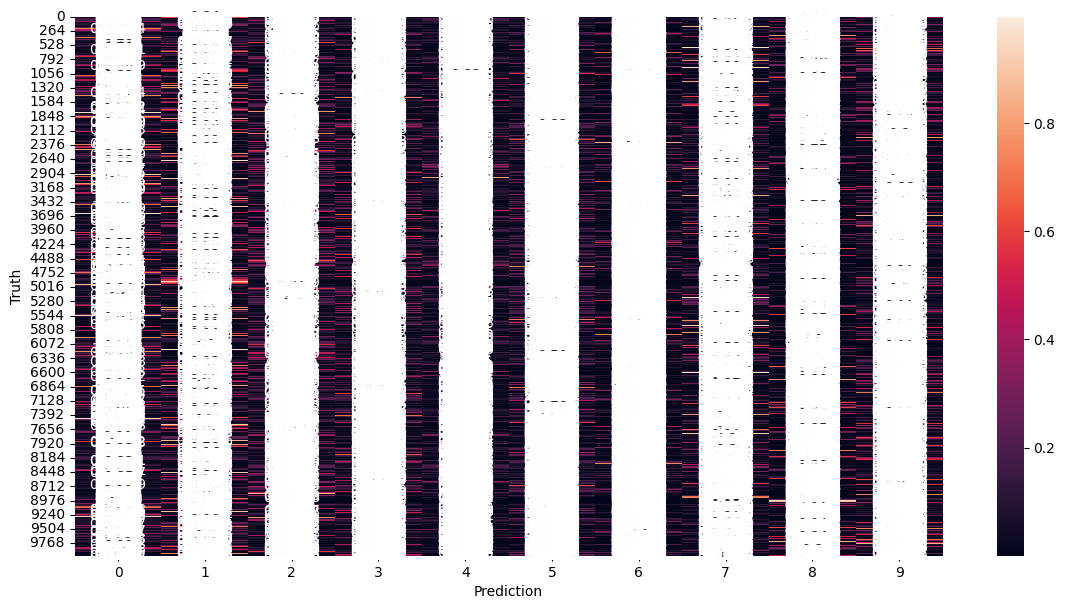

In [ ]:
plt.figure(figsize = (14,7))
sns.heatmap(predict , annot = True)
plt.ylabel("Truth")
plt.xlabel("Prediction")
plt.show()

In [ ]:
cnn = models.Sequential([
    layers.Conv2D(filters= 32 , kernel_size=(3,3) , activation = 'relu' , input_shape = (32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.conv2D(filters = 64 , kernal_size = (3,3) , activation = 'relu'),
    layers.MaxPooling2D((2,2)),

    layers.flatten(),
    layers.Dense(64 , activation = 'relu'),
    layers.Dense(10 , activation='softmax')
])